## Downscale Temperature Evaluation
Evaluate performance of downscaleTairV1 function with missing SNOTEL days.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel
import os

In [2]:
site = 'Baldy'
isAlpine = False

In [3]:
# Alpine Environmental Vars
if isAlpine:
    os.environ['SNOTEL_PATH'] = '/projects/ccox1@xsede.org/data/snotel'
    os.environ['NLDAS_PATH'] = '/projects/ccox1@xsede.org/data/nldas'


### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [4]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 33.98, Longitude: -109.5


In [5]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1988-09-27 to 2021-09-30


In [6]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

In [8]:
# Ensure dataset is complete
snotel_data = snotel_data.asfreq('D')

#### Visualization

In [9]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

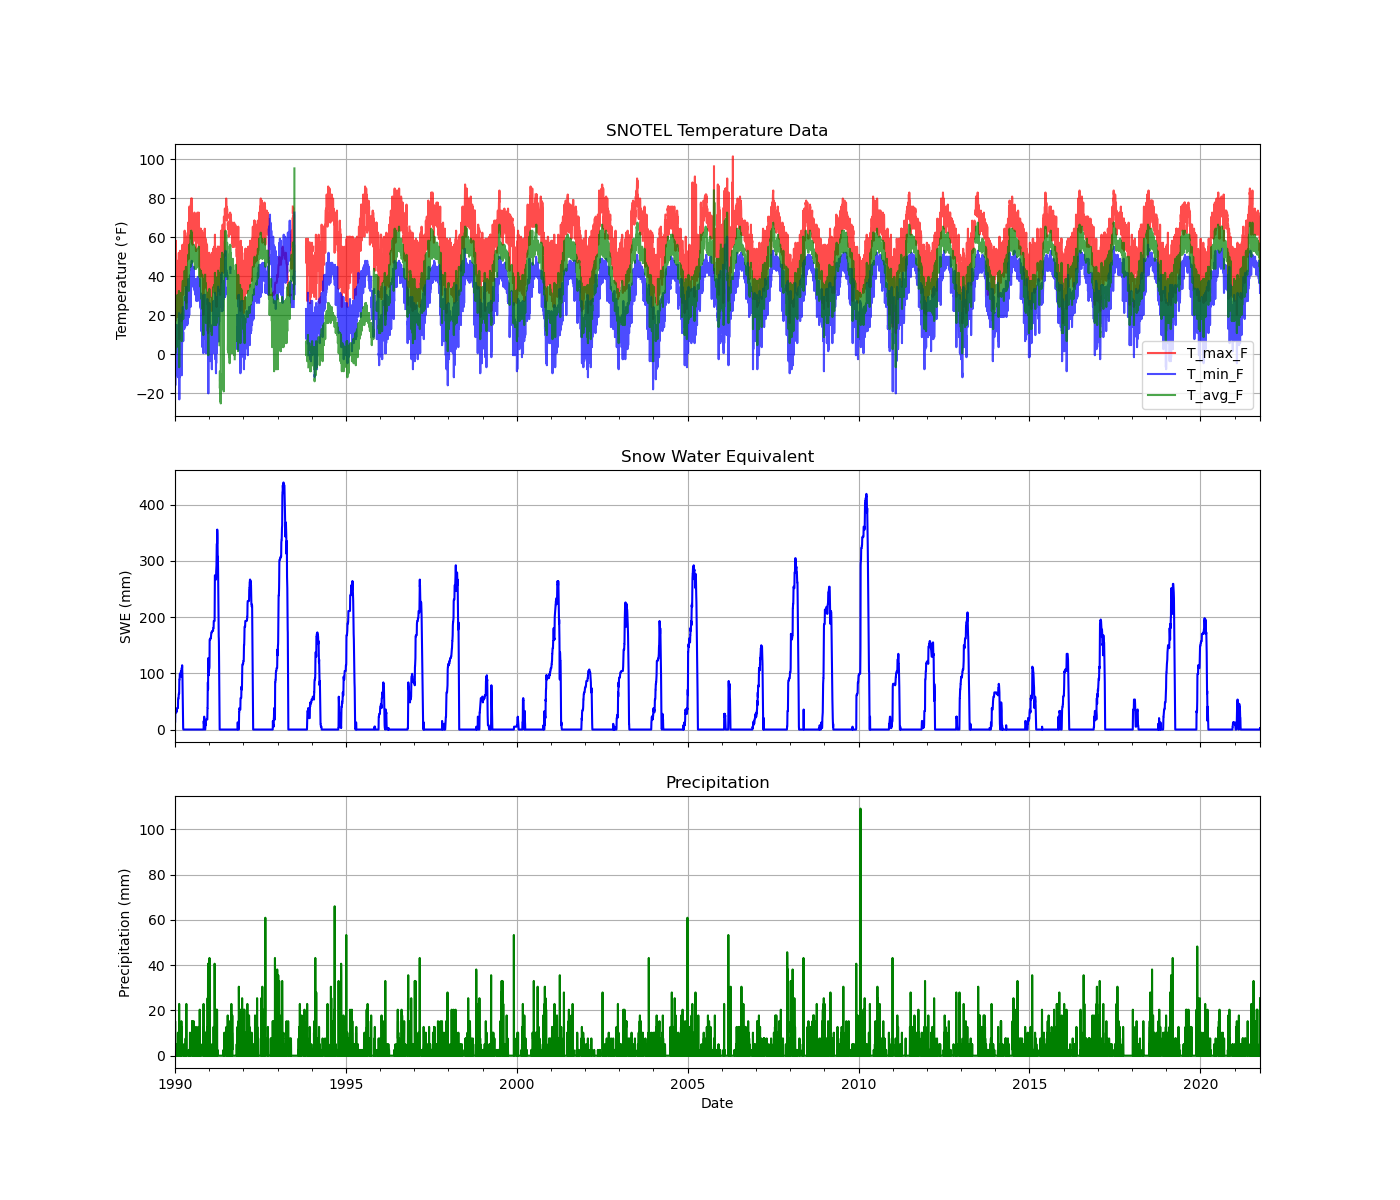

In [10]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_F', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_F', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_F', color='green', alpha=0.7)
ax1.set_ylabel('Temperature (°F)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

## Downscale Testing

Extract sections of interest for manual review.

In [ ]:
test_start = '1992-01-01'
test_end = '1994-12-31'

In [12]:
from buildforcing.downscale import downscaleTairV1
from buildforcing.datasets import siteNLDAS

In [13]:
nldas_data = siteNLDAS(snotel.latitude, snotel.longitude, start_date=datetime.strptime(test_start, '%Y-%m-%d'), end_date=datetime.strptime(test_end, '%Y-%m-%d'))
nldas_data.loadNetCDF(os.environ['NLDAS_PATH'])

In [14]:
nldas_data.data.tail()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N
Date&Time,,,,,,,,
1994-12-30 20:00:00+00:00,254.15,72041.3,0.002863,0.0000,262.509,267.53,5.28,2.53
1994-12-30 21:00:00+00:00,252.56,72050.4,0.002911,1.1308,279.296,267.70,5.25,1.83
1994-12-30 22:00:00+00:00,252.56,72098.2,0.002906,0.0000,209.072,267.61,5.12,1.67
1994-12-30 23:00:00+00:00,252.56,72145.9,0.002902,0.0000,124.624,267.51,4.99,1.52
1994-12-31 00:00:00+00:00,231.60,72193.5,0.002897,0.0000,15.512,267.42,4.86,1.36


In [15]:
nldas_Tair_downscaled = downscaleTairV1(nldas_data.data['Tair'], snotel_data.loc[test_start:test_end,'T_max_C'], snotel_data.loc[test_start:test_end,'T_min_C'])

In [25]:
# Remove snotel timezone for comparison
snotel_data_notz = snotel_data.tz_convert(nldas_data.data.index.tz)
snotel_data_notz.index

DatetimeIndex(['1990-01-01 07:00:00+00:00', '1990-01-02 07:00:00+00:00',
               '1990-01-03 07:00:00+00:00', '1990-01-04 07:00:00+00:00',
               '1990-01-05 07:00:00+00:00', '1990-01-06 07:00:00+00:00',
               '1990-01-07 07:00:00+00:00', '1990-01-08 07:00:00+00:00',
               '1990-01-09 07:00:00+00:00', '1990-01-10 07:00:00+00:00',
               ...
               '2021-09-21 07:00:00+00:00', '2021-09-22 07:00:00+00:00',
               '2021-09-23 07:00:00+00:00', '2021-09-24 07:00:00+00:00',
               '2021-09-25 07:00:00+00:00', '2021-09-26 07:00:00+00:00',
               '2021-09-27 07:00:00+00:00', '2021-09-28 07:00:00+00:00',
               '2021-09-29 07:00:00+00:00', '2021-09-30 07:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date', length=11596, freq='D')

In [27]:
nldas_Tair_downscaled.index

DatetimeIndex(['1992-01-01 00:00:00+00:00', '1992-01-01 01:00:00+00:00',
               '1992-01-01 02:00:00+00:00', '1992-01-01 03:00:00+00:00',
               '1992-01-01 04:00:00+00:00', '1992-01-01 05:00:00+00:00',
               '1992-01-01 06:00:00+00:00', '1992-01-01 07:00:00+00:00',
               '1992-01-01 08:00:00+00:00', '1992-01-01 09:00:00+00:00',
               ...
               '1994-12-30 15:00:00+00:00', '1994-12-30 16:00:00+00:00',
               '1994-12-30 17:00:00+00:00', '1994-12-30 18:00:00+00:00',
               '1994-12-30 19:00:00+00:00', '1994-12-30 20:00:00+00:00',
               '1994-12-30 21:00:00+00:00', '1994-12-30 22:00:00+00:00',
               '1994-12-30 23:00:00+00:00', '1994-12-31 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date&Time', length=26281, freq=None)

<Axes: xlabel='Date&Time'>

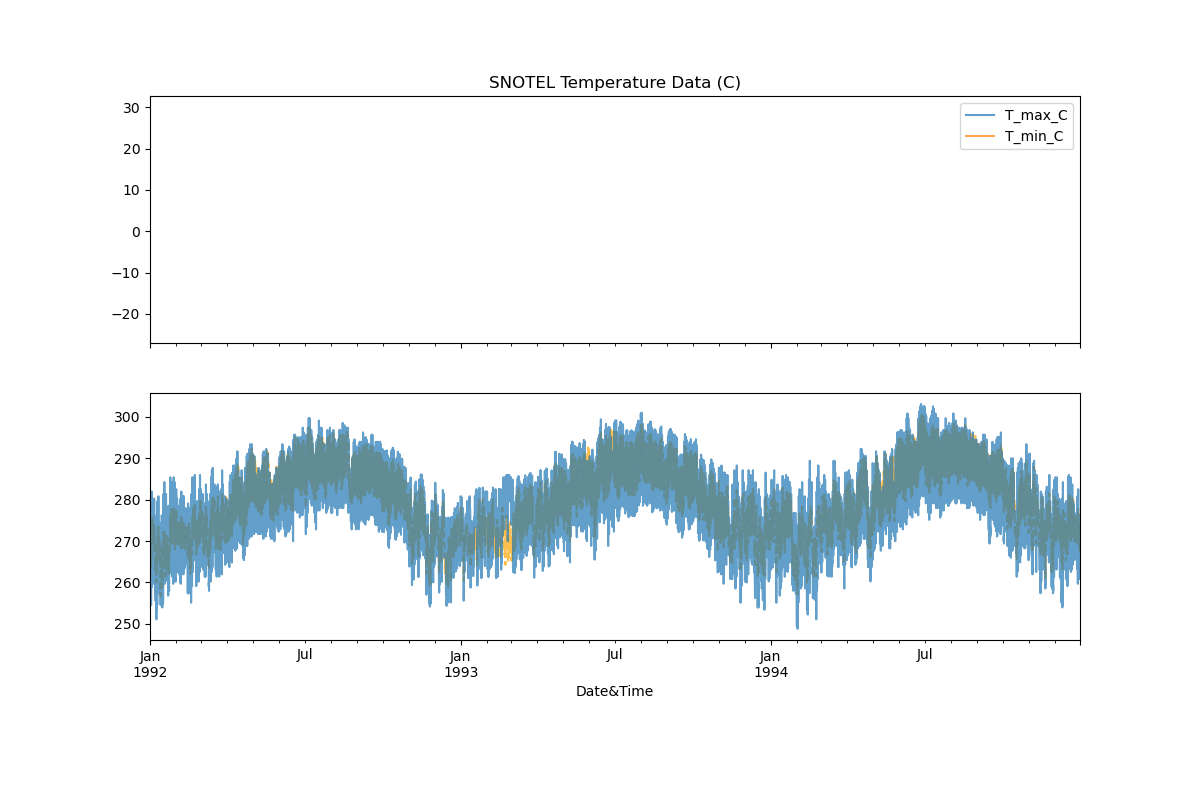

In [26]:
# Plot snotel data and downscaled data for comparison
fig, ax = plt.subplots(2,1,sharex=True, figsize=(12, 8))
snotel_data_notz.loc[test_start:test_end, ['T_max_C', 'T_min_C']].plot(ax=ax[0], title='SNOTEL Temperature Data (C)', alpha=0.7)

nldas_data.data['Tair'].plot(ax=ax[1], label='Raw NLDAS Tair (K)', color='orange', linestyle='--', alpha=0.7)
nldas_Tair_downscaled.plot(ax=ax[1], label='Downscaled NLDAS Tair (K)', alpha=0.7)
